# 05 — Feature Engineering: Time Decay & Anomaly-Prep (Akmal)
**Tujuan:** Membuat fitur temporal berbasis rolling window, EMA, dan time decay — **kritis untuk Model 3 (Anomaly Detection)**.  
**Output:** `data/processed/features_time_decay.csv`  
**Digunakan oleh:** M1, M2, M3-Anomaly (KRITIS), M5-Clustering  
> ⚠️ Semua rolling/EMA menggunakan `.shift(1)` untuk mencegah data leakage.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (14, 5)
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
print("Libraries loaded ✓")

Libraries loaded ✓


In [2]:
# ── 1. LOAD & SORT KRONOLOGIS ────────────────────────────────────────────────
df = pd.read_csv('../../data/cleaned/abis_cleaning.csv')
df = df.drop_duplicates(subset=['video_id'], keep='first').reset_index(drop=True)

df['views'] = df['penayangan_tak_dilewati']

# Parse datetime dari tanggal_upload + upload_time_wib
def parse_publish_dt(row):
    try:
        date = str(row['tanggal_upload'])
        time = str(row['upload_time_wib']).split(' ')[-1]
        return pd.to_datetime(f"{date} {time}")
    except:
        return pd.to_datetime(row['tanggal_upload'], errors='coerce')

df['publish_datetime'] = df.apply(parse_publish_dt, axis=1)
df = df.sort_values('publish_datetime').reset_index(drop=True)

print(f"Shape: {df.shape}")
print(f"Date range: {df['publish_datetime'].min()} → {df['publish_datetime'].max()}")
print(f"Monotonic ascending: {df['publish_datetime'].is_monotonic_increasing}")

Shape: (2355, 50)
Date range: 2024-12-01 15:00:06 → 2026-04-01 13:15:06
Monotonic ascending: True


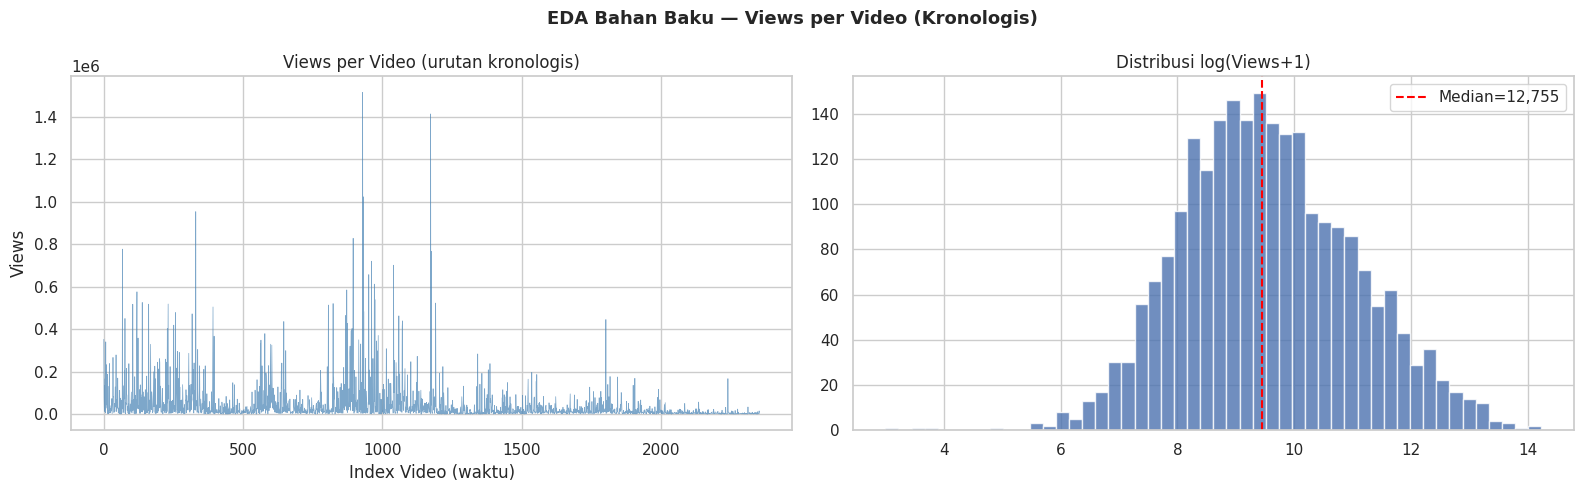

count    2.355000e+03
mean     4.280518e+04
std      9.549831e+04
min      1.900000e+01
25%      4.915000e+03
50%      1.275500e+04
75%      3.752700e+04
max      1.515626e+06


In [3]:
# ── 2. EDA BAHAN BAKU: VIEWS TIME SERIES ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('EDA Bahan Baku — Views per Video (Kronologis)', fontsize=13, fontweight='bold')

axes[0].plot(df.index, df['views'], color='steelblue', linewidth=0.5, alpha=0.7)
axes[0].set_title('Views per Video (urutan kronologis)')
axes[0].set_xlabel('Index Video (waktu)'); axes[0].set_ylabel('Views')

axes[1].hist(np.log1p(df['views']), bins=50, color='#4C72B0', edgecolor='white', alpha=0.8)
axes[1].set_title('Distribusi log(Views+1)')
axes[1].axvline(np.log1p(df['views'].median()), color='red', linestyle='--',
                label=f"Median={df['views'].median():,.0f}")
axes[1].legend()

plt.tight_layout()
plt.show()
print(df['views'].describe().to_string())

In [4]:
# ── 3. ROLLING & EMA FEATURES (anti-leakage: shift 1) ───────────────────────
W5, W7, W15 = 5, 7, 15

# 5-video rolling (leakage-safe)
df['rolling_avg_views']    = df['views'].rolling(W5,  min_periods=1).mean().shift(1).fillna(0)
df['rolling_std_views']    = df['views'].rolling(W5,  min_periods=1).std().shift(1).fillna(0)

# 7-video rolling (untuk M3 Anomaly Detection)
df['rolling_mean_views_7d'] = df['views'].rolling(W7,  min_periods=1).mean().shift(1).fillna(0)

# 15-video rolling (trend baseline)
df['rolling_avg_views_15'] = df['views'].rolling(W15, min_periods=1).mean().shift(1).fillna(0)

# EMA 5 (leakage-safe)
df['ema_views_5'] = df['views'].ewm(span=W5, min_periods=1).mean().shift(1).fillna(0)

# Trend ratio: short EMA vs long rolling (>1 = trending up)
df['views_trend_ratio'] = np.where(
    df['rolling_avg_views_15'] == 0, 1.0,
    df['ema_views_5'] / df['rolling_avg_views_15']
)

# Coefficient of variation (volatility measure)
df['rolling_cv_views'] = np.where(
    df['rolling_avg_views'] == 0, 0,
    df['rolling_std_views'] / (df['rolling_avg_views'] + 1)
)

print("Rolling/EMA features computed ✓")
df[['rolling_avg_views','rolling_mean_views_7d','ema_views_5','views_trend_ratio']].describe().round(3)

Rolling/EMA features computed ✓


,rolling_avg_views,rolling_mean_views_7d,ema_views_5,views_trend_ratio
count,2355.000,2355.000,2355.000,2355.000
mean,43004.924,43069.677,42971.843,0.994
std,53817.102,49129.019,53283.702,0.485
min,0.000,0.000,0.000,0.147
25%,10713.800,11622.571,11499.767,0.660
50%,24588.600,25846.857,24735.652,0.891
75%,50750.500,54513.143,52691.280,1.205
max,606821.800,457562.286,581611.137,4.101


In [5]:
# ── 4. TIME DECAY & VIDEO AGE ────────────────────────────────────────────────
CURRENT_DATE = df['publish_datetime'].max() + pd.Timedelta(days=1)
df['video_age_days'] = (CURRENT_DATE - df['publish_datetime'].dt.normalize()).dt.days.clip(lower=1)

HALF_LIFE = 365  # 50% relevansi hilang dalam 1 tahun
LAMBDA_DECAY = np.log(2) / HALF_LIFE
df['decay_weight'] = np.exp(-LAMBDA_DECAY * df['video_age_days'])

# Decayed historical views: estimasi views yang "relevan" secara waktu
df['decayed_historical_views'] = df['rolling_avg_views'] * df['decay_weight']

print(f"Video age: {df['video_age_days'].min()} — {df['video_age_days'].max()} hari")
print(f"Decay weight range: {df['decay_weight'].min():.4f} — {df['decay_weight'].max():.4f}")

Video age: 1 — 487 hari
Decay weight range: 0.3966 — 0.9981


In [6]:
# ── 5. ANOMALY-PREP FEATURES (kritis untuk M3) ────────────────────────────────
# views_pct_change: penurunan views dari ts3→ts4 sebagai proxy perubahan
df['ts3_views_safe'] = df['ts3_views'].replace(0, np.nan)
df['views_pct_change'] = ((df['ts4_views'] - df['ts3_views']) / df['ts3_views_safe'] * 100).fillna(0).clip(-300, 300)

# views vs channel average
channel_avg = df['views'].mean()
df['views_vs_channel_avg'] = (df['views'] / (channel_avg + 1)).round(4)

# Tren naik/turun
df['is_declining'] = (df['views_trend_ratio'] < 0.90).astype(int)

# Deviation from rolling average (z-score style)
df['views_deviation'] = np.where(
    df['rolling_std_views'] == 0, 0,
    (df['views'] - df['rolling_avg_views']) / (df['rolling_std_views'] + 1)
)

print(f"Anomaly-prep features computed ✓")
print(f"Video declining (trend_ratio < 0.9): {df['is_declining'].sum()} ({df['is_declining'].mean()*100:.1f}%)")
df[['views_pct_change','views_vs_channel_avg','is_declining','views_deviation']].describe().round(3)

Anomaly-prep features computed ✓
Video declining (trend_ratio < 0.9): 1199 (50.9%)


,views_pct_change,views_vs_channel_avg,is_declining,views_deviation
count,2355.000,2355.000,2355.000,2355.000
mean,10.636,1.000,0.509,0.866
std,24.810,2.231,0.500,5.852
min,0.000,0.000,0.000,-3.342
25%,1.011,0.115,0.000,-0.720
50%,2.602,0.298,1.000,-0.418
75%,8.359,0.877,1.000,0.468
max,300.000,35.407,1.000,191.188


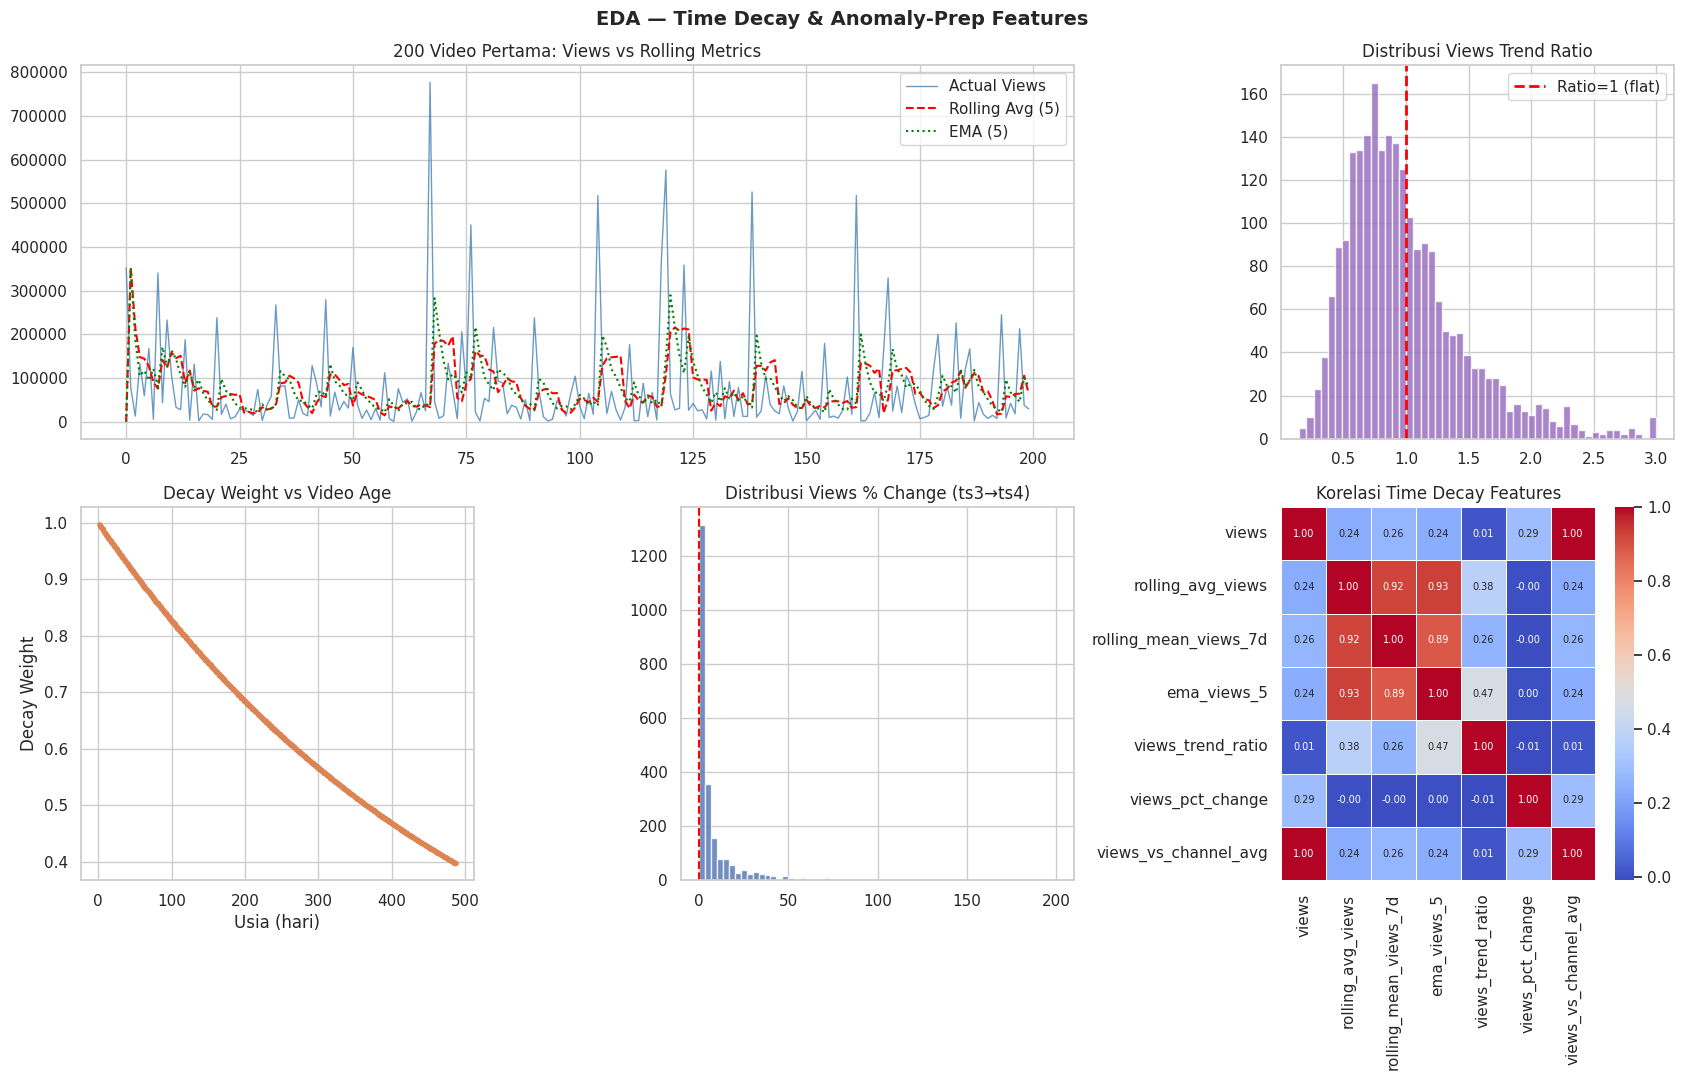

In [7]:
# ── 6. EDA FITUR TIME DECAY ──────────────────────────────────────────────────
fig = plt.figure(figsize=(17, 11))
gs  = gridspec.GridSpec(2, 3, figure=fig)
fig.suptitle('EDA — Time Decay & Anomaly-Prep Features', fontsize=14, fontweight='bold')

sample = df.head(200)

# (A) Rolling avg vs actual views
ax1 = fig.add_subplot(gs[0, :2])
ax1.plot(sample.index, sample['views'], color='steelblue', linewidth=1, label='Actual Views', alpha=0.8)
ax1.plot(sample.index, sample['rolling_avg_views'], color='red', linestyle='--', linewidth=1.5, label='Rolling Avg (5)')
ax1.plot(sample.index, sample['ema_views_5'], color='green', linestyle=':', linewidth=1.5, label='EMA (5)')
ax1.set_title('200 Video Pertama: Views vs Rolling Metrics'); ax1.legend()

# (B) Trend ratio distribution
ax2 = fig.add_subplot(gs[0, 2])
ax2.hist(df['views_trend_ratio'].clip(0, 3), bins=50, color='#9467BD', edgecolor='white', alpha=0.8)
ax2.axvline(1.0, color='red', linestyle='--', linewidth=2, label='Ratio=1 (flat)')
ax2.set_title('Distribusi Views Trend Ratio'); ax2.legend()

# (C) Decay weight vs video age
ax3 = fig.add_subplot(gs[1, 0])
ax3.scatter(df['video_age_days'], df['decay_weight'], alpha=0.3, s=8, color='#DD8452')
ax3.set_title('Decay Weight vs Video Age'); ax3.set_xlabel('Usia (hari)'); ax3.set_ylabel('Decay Weight')

# (D) views_pct_change distribution
ax4 = fig.add_subplot(gs[1, 1])
ax4.hist(df['views_pct_change'].clip(-200, 200), bins=60, color='#4C72B0', edgecolor='white', alpha=0.8)
ax4.axvline(0, color='red', linestyle='--', linewidth=1.5)
ax4.set_title('Distribusi Views % Change (ts3→ts4)')

# (E) Correlation heatmap
ax5 = fig.add_subplot(gs[1, 2])
feat = ['views','rolling_avg_views','rolling_mean_views_7d','ema_views_5',
        'views_trend_ratio','views_pct_change','views_vs_channel_avg']
corr = df[feat].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', ax=ax5, linewidths=0.5, annot_kws={'size':7})
ax5.set_title('Korelasi Time Decay Features')

plt.tight_layout()
plt.show()

In [8]:
# ── 7. VALIDASI & EXPORT ─────────────────────────────────────────────────────
time_decay_cols = [
    'video_id',
    'rolling_avg_views', 'rolling_std_views',
    'rolling_mean_views_7d', 'rolling_avg_views_15',
    'ema_views_5', 'views_trend_ratio', 'rolling_cv_views',
    'video_age_days', 'decay_weight', 'decayed_historical_views',
    'views_pct_change', 'views_vs_channel_avg',
    'is_declining', 'views_deviation'
]
df_out = df[time_decay_cols].copy()
df_out = df_out.replace([np.inf, -np.inf], np.nan).fillna(0)

print(f"Shape: {df_out.shape} | Nulls: {df_out.isnull().sum().sum()}")
display(df_out.head(3))

import os
output_path = '../../data/processed/features_time_decay.csv'
os.makedirs(os.path.dirname(output_path), exist_ok=True)
df_out.to_csv(output_path, index=False)
print(f"\n✅ Tersimpan: {output_path}")
print(f"   Kolom: {list(df_out.columns)}")

Shape: (2355, 15) | Nulls: 0


,video_id,rolling_avg_views,rolling_std_views,rolling_mean_views_7d,rolling_avg_views_15,ema_views_5,views_trend_ratio,rolling_cv_views,video_age_days,decay_weight,decayed_historical_views,views_pct_change,views_vs_channel_avg,is_declining,views_deviation
0,PsqlZW8gysU,0.0,0.0000,0.0,0.0,0.0,1.000000,0.000000,487,0.396599,0.000000,7.465969,8.2361,0,0.000000
1,q4XH6kCddq4,352554.0,0.0000,352554.0,352554.0,352554.0,1.000000,0.000000,487,0.396599,139822.610332,0.774016,1.8280,0,0.000000
2,MBi4YbptfKo,215402.5,193961.5114,215402.5,215402.5,187972.2,0.872656,0.900457,486,0.397353,85590.830105,1.308485,0.2980,1,-1.044777



✅ Tersimpan: ../../data/processed/features_time_decay.csv
   Kolom: ['video_id', 'rolling_avg_views', 'rolling_std_views', 'rolling_mean_views_7d', 'rolling_avg_views_15', 'ema_views_5', 'views_trend_ratio', 'rolling_cv_views', 'video_age_days', 'decay_weight', 'decayed_historical_views', 'views_pct_change', 'views_vs_channel_avg', 'is_declining', 'views_deviation']
